In [1]:
    import matplotlib.pyplot as plt
    import numpy as np

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 11
})

In [ ]:
SM05 = np.array(np.loadtxt("./fig2/SM_omega05.txt"))
SM3 = np.array(np.loadtxt("./fig2/SM_omega3.txt"))
SM6 = np.array(np.loadtxt("./fig2/SM_omega6.txt"))
SM10 = np.array(np.loadtxt("./fig2/SM_omega10.txt"))

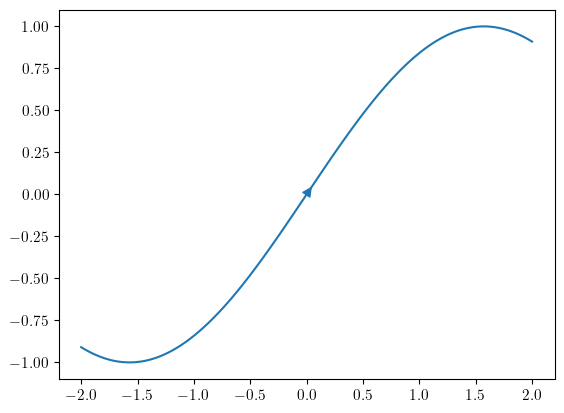

In [ ]:
#arrow on line

def add_arrow(line, position=None, direction='right', size=15, color=None):
    """
    add an arrow to a line.

    line:       Line2D object
    position:   x-position of the arrow. If None, mean of xdata is taken
    direction:  'left' or 'right'
    size:       size of the arrow in fontsize points
    color:      if None, line color is taken.
    """
    if color is None:
        color = line.get_color()

    xdata = line.get_xdata()
    ydata = line.get_ydata()

    if position is None:
        position = xdata.mean()
    # find closest index
    start_ind = np.argmin(np.absolute(xdata - position))
    if direction == 'right':
        end_ind = start_ind + 1
    else:
        end_ind = start_ind - 1

    line.axes.annotate('',
        xytext=(xdata[start_ind], ydata[start_ind]),
        xy=(xdata[end_ind], ydata[end_ind]),
        arrowprops=dict(arrowstyle="-|>", color=color),
        size=size,
        zorder=5
    )

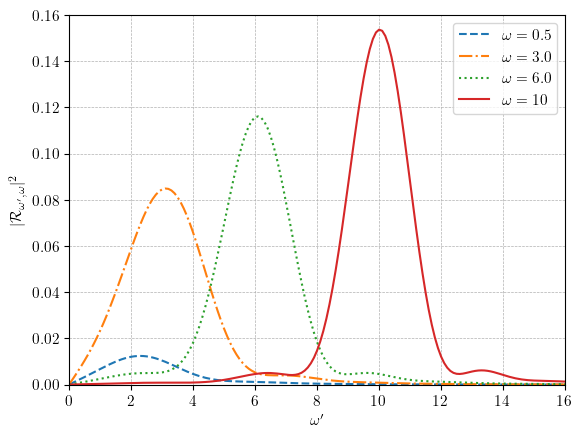

In [ ]:
# FIG2
plt.plot(SM05[:,0],SM05[:,1],linestyle='dashed', label='$\\omega=0.5$')
plt.plot(SM3[:,0],SM3[:,1],linestyle='-.', label='$\\omega=3.0$')
plt.plot(SM6[:,0],SM6[:,1],linestyle=':', label='$\\omega=6.0$')
plt.plot(SM10[:,0],SM10[:,1], label='$\\omega=10$')

plt.grid(linestyle='--',linewidth=0.5)
plt.xlim(0,16)
plt.ylim(0,0.16)

plt.legend(loc='upper right')
plt.xlabel("$\\omega'$")
plt.ylabel("$|\\mathcal{R}_{\\omega',\\omega}|^2$")

plt.savefig("./SMF.pdf",format='pdf',bbox_inches='tight')


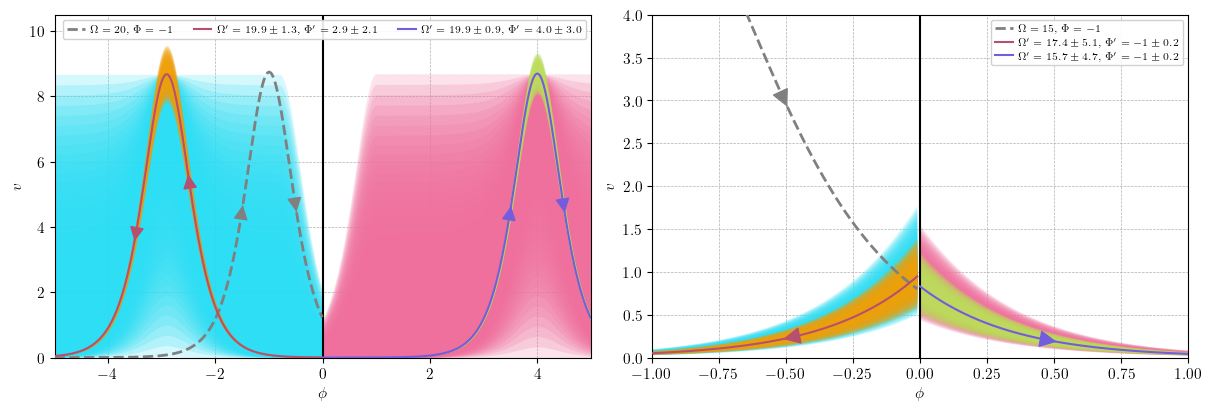

In [ ]:
# FIG1
def plot_fading_band(ax, x, y_center, y_min, y_max, color, num_layers=40, base_alpha=0.2, concentration=1.5):

    for i in range(num_layers):
        step = i / num_layers 
        fraction = (1 - step) ** concentration 
        y_lower = y_center - (y_center - y_min) * fraction
        y_upper = y_center + (y_max - y_center) * fraction
        ax.fill_between(x, y_lower, y_upper, color=color, alpha=base_alpha, lw=0, zorder=2)

# --- Global Data ---
phi_neg = np.arange(-5, 0, 0.01)
phi_pos = np.arange(0, 5, 0.01)
phi = np.arange(-5, 5, 0.01)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4), constrained_layout=True)

# ==========================================
# SUBPLOT 1 (Left)
# ==========================================
ax1.grid(linestyle='--', linewidth=0.5, zorder=1)

# Base Curve
base1 = ax1.plot(phi_neg, np.power(2*20 / (3*np.pi*np.cosh(2*(phi_neg+1))), 3/2), 
                 color='grey', linewidth=2, linestyle='--', zorder=3, 
                 label="$\\Omega = 20,\\, \\Phi=-1$")[0]
add_arrow(base1, position=-1.5, size=22)
add_arrow(base1, position=-0.5, size=22)

# Group 1
Omp1_c, f0p1_c = 19.9, -2.91
deltaOmp1, deltaf0p1 = 1.34, 2.1
y_center1 = np.power(2*Omp1_c / (3*np.pi*np.cosh(2*(phi_neg-f0p1_c))), 3/2)

f0p1_vals = np.linspace(f0p1_c-deltaf0p1, f0p1_c+deltaf0p1, 100)
Y_f0p1 = [np.power(2*Omp1_c / (3*np.pi*np.cosh(2*(phi_neg-f))), 3/2) for f in f0p1_vals]
plot_fading_band(ax1, phi_neg, y_center1, np.min(Y_f0p1, axis=0), np.max(Y_f0p1, axis=0), color='#2EDEF4')

Omp1_vals = np.linspace(Omp1_c-deltaOmp1, Omp1_c+deltaOmp1, 100)
Y_Omp1 = [np.power(2*O / (3*np.pi*np.cosh(2*(phi_neg-f0p1_c))), 3/2) for O in Omp1_vals]
plot_fading_band(ax1, phi_neg, y_center1, np.min(Y_Omp1, axis=0), np.max(Y_Omp1, axis=0), color='#EFA00B')

central1 = ax1.plot(phi_neg, y_center1, color='#B74F6F', linewidth=1.5, zorder=4, 
                    label="$\\Omega'=19.9 \\pm 1.3,\\,\\Phi'=2.9\\pm 2.1$")[0]
add_arrow(central1, direction='left', position=-2.5, size=22)
add_arrow(central1, direction='left', position=-3.5, size=22)

# Group 2
Omp2_c, f0p2_c = 19.93, 4.0
deltaOmp2, deltaf0p2 = 0.99, 3.0
y_center2 = np.power(2*Omp2_c / (3*np.pi*np.cosh(2*(phi_pos-f0p2_c))), 3/2)

f0p2_vals = np.linspace(f0p2_c-deltaf0p2, f0p2_c+deltaf0p2, 100)
Y_f0p2 = [np.power(2*Omp2_c / (3*np.pi*np.cosh(2*(phi_pos-f))), 3/2) for f in f0p2_vals]
plot_fading_band(ax1, phi_pos, y_center2, np.min(Y_f0p2, axis=0), np.max(Y_f0p2, axis=0), color='#ef709d')

Omp2_vals = np.linspace(Omp2_c-deltaOmp2, Omp2_c+deltaOmp2, 100)
Y_Omp2 = [np.power(2*O / (3*np.pi*np.cosh(2*(phi_pos-f0p2_c))), 3/2) for O in Omp2_vals]
plot_fading_band(ax1, phi_pos, y_center2, np.min(Y_Omp2, axis=0), np.max(Y_Omp2, axis=0), color='#BDDD5C')

central2 = ax1.plot(phi_pos, y_center2, color='#735CDD', linewidth=1.5, zorder=4, 
                    label="$\\Omega'=19.9 \\pm 0.9,\\,\\Phi'=4.0\\pm 3.0$")[0]
add_arrow(central2, position=4.5, size=22)
add_arrow(central2, position=3.5, size=22)

ax1.axvline(x=0, color='black', linestyle='-')
ax1.set_xlim(-5, 5)
ax1.set_ylim(0, 10.5)
ax1.set_xlabel("$\\phi$")
ax1.set_ylabel("$v$")
ax1.set_title("$\\omega=0.01$")

ax1.legend(loc='best', fontsize=7.5, labelspacing=0.3, handlelength=1.7, handletextpad=0.5, framealpha=0.9, ncols=3)

# ==========================================
# SUBPLOT 2 (Right)
# ==========================================
ax2.grid(linestyle='--', linewidth=0.5, zorder=1)

# Base Curve
base2 = ax2.plot(phi_neg, np.power(2*15 / (3*np.pi*np.cosh(2*(phi_neg+1))), 3/2), 
                 color='grey', linewidth=2, linestyle='--', zorder=3, 
                 label="$\\Omega = 15,\\, \\Phi=-1$")[0]
add_arrow(base2, position=-0.5, size=27)

# Group 1
Omp1_c, f0p1_c = 17.44, 1
deltaOmp1, deltaf0p1 = 5.1, 0.22
y_center1_sub2 = np.power(2*Omp1_c / (3*np.pi*np.cosh(2*(phi_neg-f0p1_c))), 3/2)

f0p1_vals_sub2 = np.linspace(f0p1_c-deltaf0p1, f0p1_c+deltaf0p1, 100)
Y_f0p1_sub2 = [np.power(2*Omp1_c / (3*np.pi*np.cosh(2*(phi_neg-f))), 3/2) for f in f0p1_vals_sub2]
plot_fading_band(ax2, phi_neg, y_center1_sub2, np.min(Y_f0p1_sub2, axis=0), np.max(Y_f0p1_sub2, axis=0), color='#2EDEF4')

Omp1_vals_sub2 = np.linspace(Omp1_c-deltaOmp1, Omp1_c+deltaOmp1, 100)
Y_Omp1_sub2 = [np.power(2*O / (3*np.pi*np.cosh(2*(phi_neg-f0p1_c))), 3/2) for O in Omp1_vals_sub2]
plot_fading_band(ax2, phi_neg, y_center1_sub2, np.min(Y_Omp1_sub2, axis=0), np.max(Y_Omp1_sub2, axis=0), color='#EFA00B' )

central1_sub2 = ax2.plot(phi_neg, y_center1_sub2, color='#B74F6F', linewidth=1.5, zorder=4, 
                         label="$\\Omega' = 17.4\\pm 5.1,\\, \\Phi'=-1 \\pm 0.2$")[0]
add_arrow(central1_sub2, position=-0.5, direction='left', size=27)

# Group 2
Omp2_c, f0p2_c = 15.67, -1
deltaOmp2, deltaf0p2 = 4.7, 0.22
y_center2_sub2 = np.power(2*Omp2_c / (3*np.pi*np.cosh(2*(phi_pos-f0p2_c))), 3/2)

f0p2_vals_sub2 = np.linspace(f0p2_c-deltaf0p2, f0p2_c+deltaf0p2, 100)
Y_f0p2_sub2 = [np.power(2*Omp2_c / (3*np.pi*np.cosh(2*(phi_pos-f))), 3/2) for f in f0p2_vals_sub2]
plot_fading_band(ax2, phi_pos, y_center2_sub2, np.min(Y_f0p2_sub2, axis=0), np.max(Y_f0p2_sub2, axis=0), color='#ef709d')

Omp2_vals_sub2 = np.linspace(Omp2_c-deltaOmp2, Omp2_c+deltaOmp2, 100)
Y_Omp2_sub2 = [np.power(2*O / (3*np.pi*np.cosh(2*(phi_pos-f0p2_c))), 3/2) for O in Omp2_vals_sub2]
plot_fading_band(ax2, phi_pos, y_center2_sub2, np.min(Y_Omp2_sub2, axis=0), np.max(Y_Omp2_sub2, axis=0),color='#BDDD5C')

central2_sub2 = ax2.plot(phi_pos, y_center2_sub2, color='#735CDD', linewidth=1.5, zorder=4, 
                         label="$\\Omega' = 15.7\\pm 4.7,\\, \\Phi'=-1 \\pm 0.2$")[0]
add_arrow(central2_sub2, position=0.5, size=27)

ax2.axvline(x=0, color='black', linestyle='-')
ax2.set_xlim(-1, 1)
ax2.set_ylim(0, 4)
ax2.set_xlabel("$\\phi$")
ax2.set_ylabel("$v$")
ax2.set_title("$\\omega=0.15$")

ax2.legend(loc='best', fontsize=7.5, labelspacing=0.3, handlelength=1.7, handletextpad=0.5, framealpha=0.9)

# Save the combined figure
plt.savefig("./fig1.pdf", format='pdf', bbox_inches='tight')
plt.show()